# Importacion de funciones  

In [1]:
import dolfinx
import gmsh
import numpy as np
from mpi4py import MPI
from petsc4py import PETSc
from dolfinx.fem import (Constant, Function, dirichletbc,assemble_vector)
from dolfinx.fem.petsc import  (NonlinearProblem,apply_lifting, set_bc)
from dolfinx.io import gmshio
from ufl import (TestFunctions, div,dx, dot, inner, grad, split)
from dolfinx.nls.petsc import NewtonSolver
import basix.ufl
from dolfinx.io import XDMFFile
from pydmd import DMD
from dolfinx.io import VTKFile
from dolfinx.fem.petsc import create_vector
from petsc4py import PETSc
from dolfinx.fem.petsc import assemble_vector, apply_lifting, set_bc
from dolfinx import fem
from ufl import TestFunction, TrialFunction, TestFunctions, derivative
from petsc4py import PETSc
import ufl
from dolfinx.fem.petsc import create_vector
from petsc4py import PETSc
from dolfinx.fem.petsc import assemble_vector, apply_lifting, set_bc
from dolfinx import fem
from ufl import TestFunction, TrialFunction, TestFunctions, derivative
from petsc4py import PETSc
import ufl
from dolfinx.fem import form, assemble_vector
import dolfinx
from dolfinx import log
import os
import numpy as np
from dolfinx import fem, io
from mpi4py import MPI

print(dolfinx.__version__)

0.8.0


## Computational Domain Construction and Mesh Generation

The computational domain considered in this study consists of a two-dimensional channel containing a circular obstacle. This configuration corresponds to one of the most widely used benchmark problems in computational fluid dynamics, as it exhibits several important flow phenomena including boundary-layer development, flow separation, vortex shedding, and wake formation behind the cylinder.

The geometry is defined as a rectangular channel of length (L=2.2) and height (H=0.41), containing a circular obstacle of radius

$$
r = 0.05,
$$

whose center is located at

$$
(c_x,c_y)=(0.2,0.2).
$$

The fluid domain is obtained by subtracting the circular obstacle from the rectangular channel, yielding a multiply connected region in which the fluid flows around the solid body. Mathematically, the computational domain can be expressed as

$$
\Omega
=

\Omega_{\mathrm{channel}}
\setminus
\Omega_{\mathrm{obstacle}}.
$$

The resulting geometry contains four distinct boundary regions, each associated with a specific physical condition:

* **Inlet boundary**: where the incoming flow enters the computational domain.
* **Outlet boundary**: where the fluid leaves the domain.
* **Channel walls**: corresponding to the upper and lower boundaries of the channel.
* **Obstacle boundary**: representing the surface of the circular cylinder.

To facilitate the application of boundary conditions in the finite element formulation, each boundary is assigned a unique physical marker. These markers provide a direct correspondence between the geometric entities and the mathematical conditions imposed on the governing equations.

The fluid region is also assigned a physical volume marker, allowing the finite element assembly procedures to distinguish the computational domain from its surrounding geometric entities.

## Adaptive Mesh Refinement Around the Cylinder

Accurate resolution of the flow around the obstacle is essential because the largest velocity gradients, pressure variations, and vorticity structures occur in the vicinity of the cylinder surface.

To capture these phenomena efficiently, a nonuniform mesh is employed. Rather than using a uniformly fine discretization throughout the entire channel, local mesh refinement is introduced near the obstacle while maintaining a coarser mesh farther away from the region of interest.

The mesh refinement strategy is based on the distance from the obstacle boundary. Let

$$
d(\mathbf{x})
$$

denote the shortest distance between a point in the domain and the cylinder surface. The local element size is then prescribed as a function of this distance.

Near the obstacle, where

$$
d(\mathbf{x}) \le r,
$$

the mesh adopts a minimum characteristic length

$$
h_{\min}
=

\frac{r}{8},
$$

providing enhanced spatial resolution of the boundary layer and wake structures.

As the distance from the obstacle increases, the characteristic element size gradually transitions toward a larger value

$$
h_{\max}
=

0.1H,
$$

thereby reducing the total number of elements required in regions where the solution varies more smoothly.

This adaptive refinement strategy concentrates computational resources in the areas of greatest physical relevance while maintaining a manageable overall problem size.

## High-Order Finite Element Mesh

After defining the geometry and refinement fields, the computational domain is discretized into finite elements.

The generated mesh consists of second-order elements, meaning that the geometric representation and solution approximation employ quadratic interpolation functions. Compared with linear elements, second-order discretizations provide improved accuracy in the representation of curved boundaries and offer superior approximation properties for velocity and pressure fields.

The mesh is subsequently optimized to improve element quality and reduce geometric distortions. High-quality elements contribute to better numerical conditioning, improved convergence of iterative solvers, and increased overall accuracy of the finite element solution.

## Finite Element Representation of the Flow Domain

The final mesh constitutes the discrete representation of the computational domain used in the finite element formulation of the incompressible Navier–Stokes equations.

Let

$$
\Omega_h
=

\bigcup_{e=1}^{N_e}
K_e
$$

denote the finite element partition of the domain, where (K_e) represents an individual mesh element and (N_e) is the total number of elements.

The mesh defines the finite-dimensional approximation spaces employed to represent the velocity and pressure fields throughout the simulation. Consequently, the quality and distribution of the mesh directly influence the accuracy with which important flow features—such as stagnation points, recirculation regions, pressure gradients, and vortex structures—can be captured.

The resulting discretized domain serves as the foundation for all subsequent numerical computations, including finite element assembly, nonlinear solution procedures, and reduced-order modeling analyses.


In [2]:
mesh_comm = MPI.COMM_WORLD
model_rank = 0

gmsh.initialize()

# Geometria del canal (Segun foto)

L = 2.2
H = 0.41
c_x = c_y = 0.2
r = 0.05
gdim = 2

# Creación de las entidades geométricas (un cilindro dentro de un rectángulo)
if mesh_comm.rank == model_rank:
    rectangle = gmsh.model.occ.addRectangle(0, 0, 0, L, H, tag=1)
    obstacle = gmsh.model.occ.addDisk(c_x, c_y, 0, r, r)

# substrayendo el solido del canal 
if mesh_comm.rank == model_rank:
    fluid = gmsh.model.occ.cut([(gdim, rectangle)], [(gdim, obstacle)])
    gmsh.model.occ.synchronize()


# Para que GMSH malla el fluido, añadimos un marcador de volumen físico

fluid_marker = 1
if mesh_comm.rank == model_rank:
    volumes = gmsh.model.getEntities(dim=gdim)
    assert (len(volumes) == 1)
    gmsh.model.addPhysicalGroup(volumes[0][0], [volumes[0][1]], fluid_marker)
    gmsh.model.setPhysicalName(volumes[0][0], fluid_marker, "Fluid")

# Diferentes entidades del modelo

inlet_marker, outlet_marker, wall_marker, obstacle_marker = 2, 3, 4, 5
inflow, outflow, walls, obstacle = [], [], [], []

if mesh_comm.rank == model_rank:
    boundaries = gmsh.model.getBoundary(volumes, oriented=False)
    for boundary in boundaries:
        center_of_mass = gmsh.model.occ.getCenterOfMass(boundary[0], boundary[1])
        if np.allclose(center_of_mass, [0, H / 2, 0]):
            inflow.append(boundary[1])
        elif np.allclose(center_of_mass, [L, H / 2, 0]):
            outflow.append(boundary[1])
        elif np.allclose(center_of_mass, [L / 2, H, 0]) or np.allclose(center_of_mass, [L / 2, 0, 0]):
            walls.append(boundary[1])
        else:
            obstacle.append(boundary[1])
    gmsh.model.addPhysicalGroup(1, walls, wall_marker)
    gmsh.model.setPhysicalName(1, wall_marker, "Walls")
    gmsh.model.addPhysicalGroup(1, inflow, inlet_marker)
    gmsh.model.setPhysicalName(1, inlet_marker, "Inlet")
    gmsh.model.addPhysicalGroup(1, outflow, outlet_marker)
    gmsh.model.setPhysicalName(1, outlet_marker, "Outlet")
    gmsh.model.addPhysicalGroup(1, obstacle, obstacle_marker)
    gmsh.model.setPhysicalName(1, obstacle_marker, "Obstacle")


# Malla variable para resolver la solucion en el area de interes

res_min = r / 8
if mesh_comm.rank == model_rank:
    distance_field = gmsh.model.mesh.field.add("Distance")
    gmsh.model.mesh.field.setNumbers(distance_field, "EdgesList", obstacle)
    threshold_field = gmsh.model.mesh.field.add("Threshold")
    gmsh.model.mesh.field.setNumber(threshold_field, "IField", distance_field)
    gmsh.model.mesh.field.setNumber(threshold_field, "LcMin", res_min)
    gmsh.model.mesh.field.setNumber(threshold_field, "LcMax", 0.1 * H)
    gmsh.model.mesh.field.setNumber(threshold_field, "DistMin", r)
    gmsh.model.mesh.field.setNumber(threshold_field, "DistMax", 1* H)
    min_field = gmsh.model.mesh.field.add("Min")
    gmsh.model.mesh.field.setNumbers(min_field, "FieldsList", [threshold_field])
    gmsh.model.mesh.field.setAsBackgroundMesh(min_field)


# Generacion de malla

# Todos los elementos relacionados a la malla deben ir aca 
if mesh_comm.rank == model_rank:
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.SubdivisionAlgorithm", 1)
    gmsh.model.mesh.generate(gdim)
    gmsh.model.mesh.setOrder(2)
    gmsh.model.mesh.optimize("Netgen")

# Cargando malla y contorno de la geometria 

# Informacion sobre la malla que me base : https://jsdokken.com/src/tutorial_gmsh.html 

mesh, c, ft = gmshio.model_to_mesh(gmsh.model, mesh_comm, model_rank, gdim=gdim)
mesh.name = "Cylinder"
c.name = "Cell markers"
ft.name = "Facet markers"

gmsh.fltk.run()

gmsh.finalize()


Info    : Meshing 1D...                                                                                                                        
Info    : [  0%] Meshing curve 5 (Ellipse)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 50%] Meshing curve 7 (Line)
Info    : [ 70%] Meshing curve 8 (Line)
Info    : [ 90%] Meshing curve 9 (Line)
Info    : Done meshing 1D (Wall 0.00748496s, CPU 0.006643s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Simple recombination completed (Wall 0.00850099s, CPU 0.008336s): 562 quads, 182 triangles, 0 invalid quads, 0 quads with Q < 0.1, avg Q = 0.769758, min Q = 0.500071
Info    : Simple recombination completed (Wall 0.0231967s, CPU 0.023196s): 2794 quads, 0 triangles, 0 invalid quads, 0 quads with Q < 0.1, avg Q = 0.80769, min Q = 0.484315
Info    : Done meshing 2D (Wall 0.0523061s, CPU 0.05236s)
Info    : Refining mesh...
Info    : Meshing order 2 (curvilinear on)...
Info    : [  0%] Meshing curve 5 or

## Finite Element Formulation for Flow Around a Circular Cylinder

Following the construction and discretization of the computational domain, the incompressible Navier–Stokes equations are solved using a mixed finite element formulation. The objective is to compute the transient evolution of the velocity and pressure fields as the fluid flows around the circular obstacle.

The governing equations for incompressible flow are given by

$$
\frac{\partial \mathbf{u}}{\partial t}
+
(\mathbf{u}\cdot\nabla)\mathbf{u}
-

\nu\nabla^2\mathbf{u}
+
\nabla p
=

\mathbf{0}
\qquad \text{in } \Omega,
$$

together with the incompressibility constraint

$$
\nabla\cdot\mathbf{u}=0
\qquad \text{in } \Omega,
$$

where (\mathbf{u}) denotes the velocity field, (p) the pressure field, and (\nu) the kinematic viscosity.

The simulation is performed over a finite time interval

$$
t \in [0,T],
$$

with

$$
T = 3~\mathrm{s},
$$

using a constant time step

$$
\Delta t = 0.01~\mathrm{s}.
$$

The temporal discretization is based on the generalized (\theta)-scheme. In this work,

$$
\theta = 1,
$$

which corresponds to the fully implicit Backward Euler method. This scheme is first-order accurate in time and is well known for its robustness and unconditional stability properties in transient fluid flow simulations.

## Mixed Finite Element Approximation

The velocity and pressure fields are approximated using the classical Taylor–Hood finite element pair. Specifically, the velocity field is represented using quadratic Lagrange elements, while the pressure field is approximated using linear Lagrange elements.

The discrete approximation spaces are therefore defined as

$$
V_h =
\left\{
\mathbf{v}_h \in [C^0(\Omega)]^2 :
\mathbf{v}_h|_K \in [P_2(K)]^2
\right\}
$$

and

$$
Q_h =
\left\{
q_h \in C^0(\Omega)
:
q_h|_K \in P_1(K)
\right\}
$$

where (P_k(K)) denotes the space of polynomials of degree (k) defined on element (K).

The complete mixed approximation space is then given by

$$
W_h
=

V_h
\times
Q_h.
$$

This Taylor–Hood discretization satisfies the Ladyzhenskaya–Babuška–Brezzi (LBB) stability condition and is widely employed in incompressible flow simulations due to its favorable stability and accuracy characteristics.

## Variational Formulation

Let

$$
(\mathbf{u}_h,p_h)\in W_h
$$

denote the unknown discrete solution and

$$
(\mathbf{v}_h,q_h)\in W_h
$$

the corresponding test functions.

The transient finite element formulation seeks a solution satisfying

$$
F(\mathbf{u}_h,p_h)=0,
$$

where the nonlinear residual functional is composed of four principal contributions:

1. Temporal acceleration.
2. Viscous diffusion.
3. Nonlinear convective transport.
4. Incompressibility constraint.

Using the (\theta)-method, the weak formulation may be expressed as

$$
\begin{aligned}
F
=

&
\left(
\frac{\mathbf{u}^{n+1}-\mathbf{u}^{n}}
{\Delta t},
\mathbf{v}
\right)
\
&
+
\theta
\nu
(\nabla \mathbf{u}^{n+1},
\nabla \mathbf{v})
\
&
+
\theta
\left(
(\mathbf{u}^{n+1}\cdot\nabla)\mathbf{u}^{n+1},
\mathbf{v}
\right)
\
&
+
(1-\theta)
\nu
(\nabla \mathbf{u}^{n},
\nabla \mathbf{v})
\
&
+
(1-\theta)
\left(
(\mathbf{u}^{n}\cdot\nabla)\mathbf{u}^{n},
\mathbf{v}
\right)
\
&
-

(p^{n+1},
\nabla\cdot\mathbf{v})
\
&
-

(q,
\nabla\cdot\mathbf{u}^{n+1}).
\end{aligned}
$$

The resulting formulation yields a coupled nonlinear system for the velocity and pressure unknowns at every time step.

## Boundary Conditions

The flow enters the channel through the inlet boundary with a prescribed uniform horizontal velocity profile

$$
\mathbf{u}_{\mathrm{in}}
=

(U_0,0),
$$

where

$$
U_0=1.5~\mathrm{m/s}.
$$

This boundary condition establishes a constant inflow velocity throughout the height of the channel and serves as the driving mechanism of the flow.

On the upper and lower channel walls, as well as on the surface of the circular cylinder, no-slip boundary conditions are imposed. Therefore,

$$
\mathbf{u}
=

\mathbf{0}
\qquad
\text{on }
\Gamma_{\mathrm{walls}},
$$

and

$$
\mathbf{u}
=

\mathbf{0}
\qquad
\text{on }
\Gamma_{\mathrm{cylinder}}.
$$

These conditions enforce zero velocity at all solid boundaries and allow the formation of boundary layers around the cylinder surface.

At the outlet boundary, a reference pressure condition is prescribed,

$$
p=0
\qquad
\text{on }
\Gamma_{\mathrm{outlet}},
$$

which removes the pressure indeterminacy inherent to incompressible flow problems and provides a physically meaningful outlet condition.

## Nonlinear Solution Procedure

The finite element discretization of the Navier–Stokes equations results in a nonlinear algebraic system that must be solved at every time step.

Let

$$
\mathbf{W}
=

\begin{bmatrix}
\mathbf{u}
\
p
\end{bmatrix}
$$

denote the vector of unknown degrees of freedom. The discrete problem can be written as

$$
\mathbf{R}(\mathbf{W})
=

\mathbf{0},
$$

where (\mathbf{R}) is the nonlinear residual vector obtained from the finite element formulation.

The nonlinear system is solved using Newton's method. At iteration (k), the correction is obtained from

$$
\mathbf{J}
\left(
\mathbf{W}^{(k)}
\right)
\Delta\mathbf{W}^{(k)}
=

*

\mathbf{R}
\left(
\mathbf{W}^{(k)}
\right),
$$

where

$$
\mathbf{J}
=

\frac{\partial \mathbf{R}}
{\partial \mathbf{W}}
$$

is the Jacobian matrix of the nonlinear residual.

The iterative process continues until the residual satisfies the convergence criteria

$$
|\mathbf{R}|
<
10^{-8},
$$

for both relative and absolute tolerances.

## Linear Solver Configuration

At each Newton iteration, a large sparse linear system must be solved. This task is performed using the Generalized Minimal Residual method (GMRES), which belongs to the family of Krylov subspace iterative solvers and is particularly suitable for nonsymmetric systems arising from the Navier–Stokes equations.

To improve robustness, a direct LU factorization is employed as a preconditioner. The factorization is performed using the MUMPS parallel sparse solver, which is capable of efficiently handling large finite element systems in distributed-memory environments.

The combination of Newton's method, GMRES, and MUMPS provides a robust numerical framework capable of resolving the strongly coupled velocity–pressure system associated with flow around a circular cylinder while maintaining high levels of accuracy and numerical stability.


In [ ]:

dt = Constant(mesh, PETSc.ScalarType(0.01))
nu = Constant(mesh, PETSc.ScalarType(0.001/1)) 

# Tiempo final Simulacion-[S]

T = 3

# Tipo de paso de tiempo- thetha=1/backward euler - 0.5-crank-nicholson 
theta = 1

# Velocidad de entrada 
U_0 = 1.5

# Inlet velocity profile
def u_in_eval(x: np.typing.NDArray[np.float64]) -> np.typing.NDArray[  
        PETSc.ScalarType]:
    """Return the flat velocity profile at the inlet."""
    values = np.zeros((2, x.shape[1]))
    values[0, :] = U_0 
    return values

def u_wall_eval(x: np.typing.NDArray[np.float64]) -> np.typing.NDArray[  
        PETSc.ScalarType]:
    """Return the zero velocity at the wall."""
    return np.zeros((2, x.shape[1]))

# Formulacion VAriacional 

V_element = basix.ufl.element("Lagrange", mesh.basix_cell(), 2, shape=(mesh.geometry.dim, ))
Q_element = basix.ufl.element("Lagrange", mesh.basix_cell(), 1)

W_element = basix.ufl.mixed_element([V_element, Q_element])
W = dolfinx.fem.functionspace(mesh, W_element)

V, _ = W.sub(0).collapse()
Q, _ = W.sub(1).collapse()

fdim = mesh.topology.dim - 1

up = Function(W)
u, p = split(up)
up_old = Function(W)
u_old, p_old = split(up_old)
(v, q) = TestFunctions(W)

F = ((1/dt)*dot(u - u_old, v)
  + (theta)*nu * inner(grad(u), grad(v))
  + (theta)*dot(dot(grad(u),u),v)
  + (1-theta)*nu * inner(grad(u_old), grad(v))
  + (1-theta)*dot(dot(grad(u_old),u_old),v)
  - p * div(v)
  - q * div(u)
    ) * dx


############################################ Condiciones de contorno ###################################################################################################

def Inflow(x):
    # return np.abs(x[0] - 0.) < DOLFIN_EPS
	return  np.isclose(x[0], 0)


def Walls(x):
	return np.logical_or(np.isclose(x[1], 0), np.isclose(x[1], H))


def Obstacle(x):
    return np.isclose(np.sqrt(x[0]**2 + x[1]**2), r)

# Entrada del fluido 

u_inlet = Function(V)

u_inlet.interpolate(u_in_eval)

inflow_facets = dolfinx.mesh.locate_entities_boundary(mesh, fdim,
                                                      Inflow)
inflow_dofs = dolfinx.fem.locate_dofs_topological((W.sub(0), V), fdim,
                                                  ft.indices[ft.values == 2])

bcu_inflow = dolfinx.fem.dirichletbc(u_inlet, inflow_dofs, W.sub(0))

# Paredes-condiciones de no deslizamiento 
u_nonslip = dolfinx.fem.Function(V)
u_nonslip.interpolate(u_wall_eval)
wall_facets = dolfinx.mesh.locate_entities_boundary(mesh, fdim,
                                                      Walls)
wall_dofs = dolfinx.fem.locate_dofs_topological((W.sub(0), V), fdim,
                                                  ft.indices[ft.values == 4])

bcu_walls = dolfinx.fem.dirichletbc(u_nonslip, wall_dofs, W.sub(0))

# Canal interno 
Obstacle_facets = dolfinx.mesh.locate_entities_boundary(mesh,fdim,
                                                      Obstacle)
Obstacle_dofs = dolfinx.fem.locate_dofs_topological((W.sub(0), V),fdim,
                                                  ft.indices[ft.values == 5])
bcu_obstacle = dolfinx.fem.dirichletbc(u_nonslip, Obstacle_dofs, W.sub(0))


# Condicion de salida-presion 
p_outlet = PETSc.ScalarType(0)
outflow_dofs  = dolfinx.fem.locate_dofs_topological(Q, fdim,
                                                  ft.indices[ft.values == 3])
bcp_outlet = dirichletbc(p_outlet, outflow_dofs, W.sub(1))

# Condiciones de contorno aplicadas 
bcu = [bcu_inflow, bcu_walls, bcu_obstacle]
bcp = [bcp_outlet]
bcs = bcu + bcp

# Configuracion del solver utilizado 
problem = NonlinearProblem(F, up, bcs)
solver = NewtonSolver(MPI.COMM_WORLD, problem)

# Criterios de convergencia
solver.rtol = 1e-8             # Tolerancia relativa
solver.atol = 1e-8       # Tolerancia absoluta
solver.max_it = 50           # Iteraciones máximas permitidas
solver.convergence_criterion = "residual"  # También puede ser "increment"
solver.report = True           # Muestra en consola
solver.error_on_nonconvergence = False     # No lanzar error si no converge

# Tipo de solver 
ksp = solver.krylov_solver
ksp.setTolerances(rtol=1e-8)  
opts = PETSc.Options()
option_prefix = ksp.getOptionsPrefix()
opts[f"{option_prefix}ksp_type"] = "gmres"
# opts[f"{option_prefix}ksp_view"] = None  
opts[f"{option_prefix}pc_type"] = "lu"
opts[f"{option_prefix}pc_factor_mat_solver_type"] = "mumps"

ksp.setFromOptions()
ksp.setFromOptions()


## Verification of Finite Element Spaces and Degrees of Freedom

Before proceeding with the transient simulation and reduced-order modeling stages, it is useful to verify the dimensions of the finite element spaces and the associated boundary condition structures. This verification ensures that the discretized problem has been correctly assembled and provides information regarding the computational size of the resulting algebraic system.

The mixed finite element formulation is constructed from two approximation spaces:

* The velocity space (V_h), represented by quadratic vector-valued finite elements.
* The pressure space (Q_h), represented by linear scalar finite elements.

Together, these spaces define the mixed approximation space

$$
W_h = V_h \times Q_h.
$$

The number of degrees of freedom associated with each space determines the size of the discrete problem to be solved.

Let

$$
N_V
=

\dim(V_h)
$$

denote the number of velocity degrees of freedom and

$$
N_Q
=

\dim(Q_h)
$$

the number of pressure degrees of freedom.

The total number of unknowns in the coupled velocity–pressure formulation is therefore

$$
N_W
=

N_V + N_Q.
$$

Since the velocity field is vector-valued, its dimension is generally much larger than that of the pressure space. Consequently, the velocity unknowns typically represent the dominant contribution to the overall size of the algebraic system.

## Collapsed Function Spaces

For post-processing and data management purposes, the velocity and pressure components are extracted from the mixed space and stored in independent finite element spaces.

The velocity component is projected onto a standalone space

$$
V_0,
$$

while the pressure component is projected onto

$$
Q_0.
$$

These collapsed spaces preserve the finite element representation of each variable while allowing independent manipulation of velocity and pressure data. Such a separation is particularly useful for:

* Exporting simulation results.
* Constructing snapshot matrices.
* Performing reduced-order modeling.
* Computing error metrics and residual indicators.

The dimensions of (V_0) and (Q_0) should be consistent with the dimensions of the corresponding subspaces extracted from the mixed formulation.

## Verification of Boundary Condition Structures

The numerical formulation employs several Dirichlet boundary conditions associated with the physical boundaries of the computational domain.

For the cylinder flow problem, these conditions include:

* Prescribed inlet velocity.
* No-slip condition on the channel walls.
* No-slip condition on the cylinder surface.
* Pressure reference condition at the outlet.

These constraints are grouped into velocity and pressure boundary-condition collections,

$$
\mathcal{B}_u
=

{
BC_{\mathrm{inlet}},
BC_{\mathrm{walls}},
BC_{\mathrm{cylinder}}
},
$$

and

$$
\mathcal{B}_p
=

{
BC_{\mathrm{outlet}}
}.
$$

The complete set of boundary conditions applied to the nonlinear system is then

$$
\mathcal{B}
=
\mathcal{B}_u
\cup
\mathcal{B}_p.
$$

Verifying that each element of these collections corresponds to a valid Dirichlet boundary condition object ensures that the finite element solver will correctly enforce the prescribed physical constraints during assembly and solution.

## Computational Size of the Discrete Problem

The dimensions reported for the spaces (V_h), (Q_h), and (W_h) provide a direct measure of the computational complexity of the simulation.

The velocity dimension

$$
\dim(V_h)
$$

indicates the number of unknown velocity coefficients to be computed.

Similarly,

$$
\dim(Q_h)
$$

represents the number of pressure unknowns.

The complete coupled system contains

$$
\dim(W_h)
=

\dim(V_h)
+
\dim(Q_h)
$$

degrees of freedom.

These values determine the size of the nonlinear algebraic system solved at each time step and therefore have a direct impact on memory consumption, solver performance, and computational cost.

Monitoring these dimensions is particularly important when comparing full-order and reduced-order models, since the efficiency gains obtained through model reduction are directly related to the size of the original finite element problem.


In [4]:
# Imprimimos el tamaño de los subespacios V y Q
print("Tamaño de V:", V.dofmap.index_map.size_local)
print("Tamaño de Q:", Q.dofmap.index_map.size_local)

# Espacio donde vou alamacenar velocidad 
V0, dofs = W.sub(0).collapse()

# Espacio donde vou alamacenar presion 
Q0, dofs_p = W.sub(1).collapse()

# Obtener los tamaños de V0 y Q0
print("Tamaño de V0:", V0.dofmap.index_map.size_local)
print("Tamaño de Q0:", Q0.dofmap.index_map.size_local)

bcs = [[bcu_inflow, bcu_walls, bcu_obstacle]]


print(type(bcu))  # ¿Es una lista?
print(type(bcp))  # ¿Es una lista?

print(all(isinstance(bc, dolfinx.fem.DirichletBC) for bc in bcu))  # deben ser todos DirichletBC
print(all(isinstance(bc, dolfinx.fem.DirichletBC) for bc in bcp))

print(f"Dimension V: {V.dofmap.index_map.size_global * V.dofmap.index_map_bs}")
print(f"Dimension Q: {Q.dofmap.index_map.size_global * Q.dofmap.index_map_bs}")
print(f"Dimension W: {W.dofmap.index_map.size_global * W.dofmap.index_map_bs}")

Tamaño de V: 45152
Tamaño de Q: 11400
Tamaño de V0: 45152
Tamaño de Q0: 11400
<class 'list'>
<class 'list'>
True
True
Dimension V: 90304
Dimension Q: 11400
Dimension W: 101704


## Reconstruction of the Mixed Finite Element Solution

Within the adaptive FOM–DMD framework, the velocity and pressure fields are frequently manipulated independently. In particular, the Dynamic Mode Decomposition algorithm generates separate predictions for the velocity and pressure variables, producing two independent vectors of degrees of freedom.

However, the finite element formulation of the incompressible Navier–Stokes equations is expressed in terms of a mixed solution vector belonging to the coupled approximation space

$$
W_h = V_h \times Q_h.
$$

Consequently, after obtaining independent velocity and pressure predictions, it is necessary to reconstruct a single mixed finite element function that can be used by the residual evaluation procedures, nonlinear solvers, and post-processing routines.

## Projection onto Individual Function Spaces

Let

$$
\mathbf{u}^{*}
$$

denote the vector containing the velocity degrees of freedom predicted by the reduced-order model and

$$
\mathbf{p}^{*}
$$

the corresponding pressure vector.

These discrete vectors are first associated with their respective finite element spaces,

$$
V_0
\quad \text{and} \quad
Q_0,
$$

which represent the collapsed velocity and pressure subspaces extracted from the mixed formulation.

The resulting finite element functions may be written as

$$
u_h^{*}
\in V_0,
$$

and

$$
p_h^{*}
\in Q_0.
$$

At this stage, the velocity and pressure fields exist as independent finite element objects and cannot yet be directly employed in the coupled Navier–Stokes formulation.

## Reconstruction of the Mixed State

To recover the complete finite element state, a new function is created in the mixed space

$$
W_h.
$$

The velocity approximation is then mapped to the velocity component of the mixed space, while the pressure approximation is mapped to the pressure component.

The reconstructed solution can therefore be expressed as

$$
\mathbf{w}_h^{*}
=

\begin{bmatrix}
u_h^{*}
\
p_h^{*}
\end{bmatrix}
\in W_h.
$$

This operation combines the independently predicted fields into a single object compatible with the mixed finite element formulation.

## Role Within the Adaptive FOM–DMD Framework

The reconstruction procedure constitutes a fundamental step in the online reduced-order modeling strategy. Since the DMD algorithm operates on separate snapshot matrices for velocity and pressure,

$$
\mathbf{X}_u
=

\begin{bmatrix}
u_1 & u_2 & \cdots & u_m
\end{bmatrix},
$$

and

$$
\mathbf{X}_p
=
\begin{bmatrix}
p_1 & p_2 & \cdots & p_m
\end{bmatrix},
$$

the resulting predictions are generated independently.

Before the predicted state can be validated, it must be transformed into a complete finite element solution belonging to the mixed space. The reconstructed field

$$
\mathbf{w}_h^{*}
=

(u_h^{*},p_h^{*})
$$

is subsequently used to:

* Evaluate the nonlinear residual.
* Verify the residual-based acceptance criterion.
* Compare reduced-order and full-order solutions.
* Export simulation results.
* Update the snapshot database.

Therefore, this reconstruction procedure acts as the interface between the reduced-order model and the full finite element formulation, ensuring that DMD predictions remain compatible with the numerical framework employed for the solution of the incompressible Navier–Stokes equations.


In [5]:
def transformar_Datos(u_array, p_array):
    
    # En el caso de la velocidad 
    u_proj = Function(V0)
    u_proj.x.array[:] = u_array
    u_proj.x.scatter_forward()

    # En el caso de la presion 
    p_proj = Function(Q0)
    p_proj.x.array[:] = p_array
    p_proj.x.scatter_forward()
    
    # Crear función en espacio mixto
    up = Function(W)
    u_sub, p_sub = up.split()

    # Interpolar los datos a los subespacios del espacio mixto
    u_sub.interpolate(u_proj)
    p_sub.interpolate(p_proj)
    up.x.scatter_forward()
    return up

## Nonlinear Residual Evaluation

A key component of the adaptive FOM–DMD framework is the evaluation of the nonlinear residual associated with the finite element discretization of the incompressible Navier–Stokes equations. The residual provides a quantitative measure of how accurately a given approximation satisfies the governing equations and serves as the primary criterion for accepting or rejecting reduced-order predictions.

Let

$$
\mathbf{w}_h^{n}
=

\left(
\mathbf{u}_h^{n},
p_h^{n}
\right)
$$

denote the solution at the previous time level and

$$
\mathbf{w}_h^{n+1}
=

\left(
\mathbf{u}_h^{n+1},
p_h^{n+1}
\right)
$$

represent the candidate solution to be evaluated. This candidate may originate either from the full-order finite element solver or from the Dynamic Mode Decomposition predictor.

## Residual Formulation

The nonlinear residual is constructed from the weak formulation of the incompressible Navier–Stokes equations.

Using the generalized (\theta)-scheme, the residual functional is given by

$$
\begin{aligned}
F
=

&
\left(
\frac{\mathbf{u}^{n+1}-\mathbf{u}^{n}}
{\Delta t},
\mathbf{v}
\right)
\
&
+
\theta
\nu
(\nabla\mathbf{u}^{n+1},
\nabla\mathbf{v})
\
&
+
\theta
\left(
(\mathbf{u}^{n+1}\cdot\nabla)\mathbf{u}^{n+1},
\mathbf{v}
\right)
\
&
+
(1-\theta)
\nu
(\nabla\mathbf{u}^{n},
\nabla\mathbf{v})
\
&
+
(1-\theta)
\left(
(\mathbf{u}^{n}\cdot\nabla)\mathbf{u}^{n},
\mathbf{v}
\right)
\
&
-

(p^{n+1},
\nabla\cdot\mathbf{v})
\
&
-

(q,
\nabla\cdot\mathbf{u}^{n+1}).
\end{aligned}
$$

This expression combines the transient contribution, viscous diffusion, nonlinear convection, pressure coupling, and incompressibility constraint into a single nonlinear operator.

The exact discrete solution satisfies

$$
F(\mathbf{w}_h)=0.
$$

Therefore, any deviation from zero indicates that the governing equations are not fully satisfied.

## Assembly of the Residual Vector

To evaluate the residual numerically, the weak form is assembled into a discrete residual vector

$$
\mathbf{R}
=

\mathbf{R}
\left(
\mathbf{w}_h^{n+1}
\right).
$$

This vector contains the imbalance associated with every degree of freedom of the finite element discretization.

The assembly process incorporates:

* Temporal discretization contributions.
* Convective and diffusive terms.
* Pressure–velocity coupling.
* Boundary condition corrections.
* Parallel communication between distributed mesh partitions.

After assembly, the residual vector represents the complete discrete error associated with the candidate solution.

## Jacobian-Based Boundary Treatment

Because Dirichlet boundary conditions are imposed strongly, the residual must be modified to ensure consistency with the constrained degrees of freedom.

This correction is performed through the Jacobian matrix

$$
\mathbf{J}
=

\frac{\partial \mathbf{R}}
{\partial \mathbf{W}},
$$

which corresponds to the linearization of the nonlinear finite element operator.

The lifting procedure uses the Jacobian information to correctly incorporate the prescribed boundary values into the residual evaluation. As a result, the computed residual reflects only the unconstrained degrees of freedom and provides a physically meaningful measure of the equation imbalance.

## Residual Norm

Once the residual vector has been assembled and corrected, its Euclidean norm is computed according to

$$
|\mathbf{R}|_2
=

\left(
\sum_{i=1}^{N}
R_i^2
\right)^{1/2},
$$

where (R_i) denotes the (i)-th component of the residual vector and (N) is the total number of degrees of freedom of the mixed finite element system.

The residual norm provides a scalar measure of the distance between the current approximation and the exact discrete solution.

A value close to zero indicates that the governing equations are satisfied with high accuracy, whereas larger values reveal a greater discrepancy between the candidate solution and the finite element equilibrium state.

## Role in the Adaptive FOM–DMD Framework

The residual norm plays a central role in the online reduced-order modeling strategy.

After the DMD algorithm predicts the future velocity and pressure fields, the reconstructed mixed solution

$$
\mathbf{w}_{h,\mathrm{DMD}}^{n+1}
$$

is evaluated through the residual operator. The resulting norm is then compared against a prescribed tolerance

$$
\varepsilon.
$$

If

$$
|\mathbf{R}
(
\mathbf{w}_{h,\mathrm{DMD}}^{n+1}
)
|
<
\varepsilon,
$$

the reduced-order prediction is accepted and replaces the expensive full-order simulation.

Otherwise,

$$
|\mathbf{R}
(
\mathbf{w}_{h,\mathrm{DMD}}^{n+1}
)
|
\ge
\varepsilon,
$$

and a new high-fidelity finite element solution is computed.

Consequently, the residual norm functions as a physics-based error indicator that continuously verifies whether the reduced-order approximation remains consistent with the governing equations. This mechanism allows the adaptive framework to balance computational efficiency and numerical accuracy while ensuring that reduced-order predictions are only accepted when they satisfy the underlying fluid dynamics with sufficient precision.


In [6]:
def residual(vector1, vector2):
    
    up_old = vector1
    up = vector2
    bcs = bcu + bcp  
    u, p = split(up)
    u_old, p_old = split(up_old)

    F = (
        (1/dt)*dot(u - u_old, v)
        + (theta)*nu * inner(grad(u), grad(v))
        + (theta)*dot(dot(grad(u), u), v)
        + (1-theta)*nu * inner(grad(u_old), grad(v))
        + (1-theta)*dot(dot(grad(u_old), u_old), v)
        - p * div(v)
        - q * div(u)
    ) * dx

    # Parametros de la simulacion
    jacobian = ufl.derivative(F, up)
    J_compiled = dolfinx.fem.form(jacobian)
    F_compiled = dolfinx.fem.form(F)
    b = dolfinx.fem.Function(up.function_space)
    dolfinx.fem.assemble_vector(b.x.array, F_compiled)
    dolfinx.fem.apply_lifting(b.x.array, [J_compiled], [bcs], x0=[up.x.array], scale=-1.0)
    b.x.scatter_reverse(dolfinx.la.InsertMode.add)
    set_bc(b=b.vector, bcs=bcs, x0=up.vector)
    norma = np.linalg.norm(b.x.array)

    return norma

## Adaptive Online FOM–DMD Simulation Framework

The transient flow simulation is performed using an adaptive online reduced-order modeling framework that combines a high-fidelity finite element solver with Dynamic Mode Decomposition (DMD). The objective of this methodology is to reduce the computational cost of the simulation while preserving the accuracy of the full-order model.

At the beginning of the simulation, a training stage is performed in which all solutions are computed exclusively using the finite element model. During this phase, velocity and pressure snapshots are collected and stored for the construction of the reduced-order representation.

Let

$$
\mathbf{u}_1,\mathbf{u}_2,\ldots,\mathbf{u}_m
$$

and

$$
p_1,p_2,\ldots,p_m
$$

denote the velocity and pressure snapshots obtained from the full-order model. These snapshots are assembled into the matrices

$$
\mathbf{X}_u=
\begin{bmatrix}
\mathbf{u}_1 &
\mathbf{u}_2 &
\cdots &
\mathbf{u}_m
\end{bmatrix},
$$

and

$$
\mathbf{X}_p=
\begin{bmatrix}
p_1 &
p_2 &
\cdots &
p_m
\end{bmatrix}.
$$

These matrices constitute the database used to identify the dominant dynamical structures of the flow through Dynamic Mode Decomposition.

## Initial Snapshot Collection Stage

During the first simulation steps, only full-order solutions are accepted. This initial window provides sufficient information to construct a representative reduced-order basis capable of capturing the dominant flow dynamics.

For each time step, the finite element solver computes the coupled velocity–pressure solution. The resulting fields are exported for visualization and simultaneously incorporated into the snapshot matrices.

The nonlinear residual is also evaluated at every iteration,

$$
|\mathbf{R}_n|,
$$

providing a measure of the consistency of the numerical solution with the governing equations.

In addition, the variation between consecutive states is monitored through

$$
|\mathbf{w}^{n+1}-\mathbf{w}^{n}|,
$$

which provides information regarding the temporal evolution of the solution and the approach toward a statistically stationary regime.

## Construction of the Dynamic Mode Decomposition Model

Once the snapshot database contains a sufficient number of solutions, Dynamic Mode Decomposition is applied separately to the velocity and pressure datasets.

For a generic snapshot matrix

$$
\mathbf{X},
$$

the DMD methodology approximates the underlying dynamics through a low-dimensional linear operator

$$
\mathbf{A},
$$

such that

$$
\mathbf{x}_{k+1}
\approx
\mathbf{A}\mathbf{x}_k.
$$

The construction of this operator relies on the singular value decomposition

$$
\mathbf{X}
=

\mathbf{U}
\mathbf{\Sigma}
\mathbf{V}^{T},
$$

from which the dominant dynamical modes are extracted.

Separate DMD models are therefore obtained for

$$
\mathbf{X}_u
$$

and

$$
\mathbf{X}_p,
$$

allowing independent prediction of future velocity and pressure fields.

The dimensions of the retained modal basis are monitored throughout the simulation since they provide information about the complexity of the flow dynamics represented by the reduced-order model.

## Reduced-Order Prediction

After constructing the DMD operators, future states are predicted using the most recent available snapshot.

The reduced-order approximation produces

$$
\mathbf{u}_{n+1}^{\mathrm{DMD}}
$$

for the velocity field and

$$
p_{n+1}^{\mathrm{DMD}}
$$

for the pressure field.

These quantities are subsequently reconstructed into a mixed finite element state

$$
\mathbf{w}_{n+1}^{\mathrm{DMD}}
=

\left(
\mathbf{u}*{n+1}^{\mathrm{DMD}},
p*{n+1}^{\mathrm{DMD}}
\right).
$$

This reconstructed state is fully compatible with the finite element formulation and can therefore be evaluated using the same residual operator employed by the high-fidelity solver.

## Residual-Based Acceptance Criterion

To ensure that the reduced-order approximation remains physically consistent, every DMD prediction is validated through a residual-based criterion.

The nonlinear residual associated with the predicted state is computed as

$$
\mathbf{R}
\left(
\mathbf{w}_{n+1}^{\mathrm{DMD}}
\right),
$$

and its Euclidean norm is evaluated according to

$$
\left|
\mathbf{R}
\left(
\mathbf{w}_{n+1}^{\mathrm{DMD}}
\right)
\right|.
$$

A prescribed tolerance

$$
\varepsilon = 10^{-2}
$$

is adopted as the acceptance threshold.

Whenever

$$
\left|
\mathbf{R}
\left(
\mathbf{w}_{n+1}^{\mathrm{DMD}}
\right)
\right|
<
\varepsilon,
$$

the reduced-order prediction is accepted and replaces the full-order simulation.

In this case, the DMD solution is considered sufficiently accurate and becomes the new state of the system.

Conversely, if

$$
\left|
\mathbf{R}
\left(
\mathbf{w}_{n+1}^{\mathrm{DMD}}
\right)
\right|
\ge
\varepsilon,
$$

the reduced-order approximation is rejected.

The simulation then automatically returns to the finite element solver to compute a new high-fidelity solution.

This mechanism guarantees that the reduced-order model is only employed when it satisfies the governing equations with an acceptable level of accuracy.

## Online Enrichment of the Reduced Basis

An important characteristic of the methodology is that the snapshot database continuously evolves during the simulation.

Whenever a solution is accepted, either from the DMD model or from the finite element solver, the corresponding velocity and pressure fields are appended to the snapshot matrices.

As a result,

$$
\mathbf{X}_u
\rightarrow
\mathbf{X}_u^{\mathrm{new}},
$$

and

$$
\mathbf{X}_p
\rightarrow
\mathbf{X}_p^{\mathrm{new}}.
$$

The reduced-order model is therefore continuously enriched with new information and adapts to the evolving flow dynamics.

This online updating strategy improves the predictive capabilities of the DMD approximation and reduces the likelihood of future prediction failures.

## Data Storage and Post-Processing

Throughout the simulation, all accepted solutions are exported for visualization and post-processing.

The velocity field is stored in XDMF format, while the pressure field is written using VTK-compatible files. These outputs allow subsequent analysis of velocity distributions, pressure contours, wake structures, vortex formation, and flow evolution around the cylinder.

At the end of the simulation, the complete velocity and pressure snapshot matrices are saved as numerical arrays,

$$
\mathbf{X}_u
$$

and

$$
\mathbf{X}_p,
$$

which can subsequently be employed for:

* Error analysis.
* Model validation.
* Offline reduced-order modeling studies.
* POD and DMD comparisons.
* Hyper-reduction techniques.
* Long-term dynamical analysis.

Consequently, the overall methodology constitutes an adaptive online reduced-order modeling framework in which a residual-based indicator dynamically determines whether the future state should be computed by the high-fidelity finite element solver or by the reduced-order DMD predictor, thereby balancing computational efficiency and physical accuracy throughout the simulation.


In [7]:
import warnings
warnings.filterwarnings("ignore")

# Crear archivo VTK para la presión (una vez, fuera del bucle de tiempo si usas uno)
vtkfile_p1 = VTKFile(mesh.comm, "resultados_mix/presion1.vtu", "w")

# Abrir archivo una sola vez
xdmf_u1 = XDMFFile(mesh.comm, "resultados_mix/velocity1.xdmf", "w")
xdmf_u1.write_mesh(mesh)

t = 0.0

#up_old.x.array[:] = up.x.array
up_old.x.array[:] = 0.0  

ii = 0

lista_norma_solucion=[]
lista_residual_foam=[]
datos_lista=[]
datos_lista_presion=[]
posicion_dmd=[]
posicion_fom=[]
janela=30 

# Aqui vamos a sobreescribir la tolerancia 

tolerancia = 1e-2

while t < T:
    
    if ii < janela:
        print("#" * 100 + "\n" + f"Iteracion Nº: {ii+1}")
        print("\n")

        ## Actualizamos el contador 
        ii += 1

        ## Actualizamos el paso de tiempo 
        t += float(dt)

        ## Resolvemos el paso de tiempo 
        solver.solve(up)

        ################################################################ Calculando el residuo ################################################################ 
        u_split, p_split = up.split()

        ## Exportamos los datos de la velocidad 
        u_proj = Function(V0)
        u_proj.interpolate(u_split)
        xdmf_u1.write_function(u_proj, t)
        u_array = u_proj.x.array

        ## Exportamos los datos para la presion 
        p_proj = Function(Q0)  
        p_proj.interpolate(p_split)
        vtkfile_p1.write_function(p_proj,t)
        p_array=p_proj.x.array

        ################################################################ Calculando el residuo ################################################################ 
        residual_fom=residual(up_old,up)
        print(f"Residual_FOM = {residual_fom:.3e}")
        lista_residual_foam.append(residual_fom)
        ################################################################ Calculando las normas ################################################################ 
        diff = Function(W)
        diff.x.array[:] = up.x.array - up_old.x.array
        norm_diff = diff.vector.norm()
        lista_norma_solucion.append(norm_diff)
        ################################################################ Matriz de velocidad-presion ##########################################################

        # Inicializamos Matriz array para Velocidad
        datos_lista.append(u_array) 
        matriz_vel=np.column_stack(datos_lista)
        print("Tamaño de la matriz velocidad:", matriz_vel.shape)

        # Inicializamos Matriz para Presion 
        datos_lista_presion.append(p_array) 
        matriz_pre = np.column_stack(datos_lista_presion)
        print("Tamaño de la matriz presion:", matriz_pre.shape)

        ####################################################################################################################################################### 

        print(f"Iteracion:{ii}, Tiempo: {t:.4f}")
        print("\n")
        print("#" * 100 )
        
        up_old.x.array[:] = up.x.array
        
    ######################################## Activamos la toleracia ##############################################################
    else:
        
        print("#" * 100 + "\n" + f"Iteracion Nº: {ii+1}")
        
        ## Actualizamos el contador 
        ii += 1

        ## Actualizamos el paso de tiempo 
        t += float(dt)

        ## Llamar al metodo DMD-Velocidad y para presion 

        dmd_vel=DMD(svd_rank=0, tlsq_rank=0, exact=True, opt=matriz_vel.shape[1]-1, rescale_mode=None, forward_backward=False, tikhonov_regularization=1e-6)
        dmd_pre=DMD(svd_rank=0, tlsq_rank=0, exact=True, opt=matriz_pre.shape[1]-1, rescale_mode=None, forward_backward=False,tikhonov_regularization=1e-6)

        # Aplicando DMD tanto para presion como para velocidad 
        dmd_vel.fit(matriz_vel)
        dmd_pre.fit(matriz_pre)

        # Extrayendo los valores de la descomposicion SVD
        r_vel=dmd_vel._svd_modes  
        r_pre=dmd_pre._svd_modes  

        # efectuamos  la prediccion temporal el vector de velocidad

        vector_velocidad= dmd_vel.predict(matriz_vel[:,-1])
        vector_presion=dmd_pre.predict(matriz_pre[:,-1])
        up_dmd=transformar_Datos(vector_velocidad,vector_presion)

        # Calcular el residual de la aproximacion 
        residual_dmd=residual(up,up_dmd)

        print(f"Residual_DMD_futuro = {residual_dmd:.3e}")
        print("Dimensiones de SVD para matriz de velocidad :", r_vel.shape[1])
        print("Dimensiones de SVD para matriz de presion :", r_pre.shape[1])

        if residual_dmd < tolerancia:

            print("Cumple el requidito para una Solucion Via DMD")

            # Actualizar soluciones via ROM-FOM
            posicion_dmd.append(ii)
            print(f"Soluciones DMD : {len(posicion_dmd)}")
            print(f"Soluciones FOM : {len(posicion_fom)}")

            # Actualizamos la matriz velocidad  
            datos_lista.append(vector_velocidad) 
            matriz_vel=np.column_stack(datos_lista)
            print("Tamaño de la matriz velocidad:", matriz_vel.shape)

            # Actualizamos la matriz presion 
            datos_lista_presion.append(vector_presion) 
            matriz_pre = np.column_stack(datos_lista_presion)
            print("Tamaño de la matriz presion:", matriz_pre.shape)

            # Asignamos el vector calculado en la regresion 
            up.x.array[:] = up_dmd.x.array

            # Calcular el residuo de esa cosa
            lista_residual_foam.append(residual_dmd)
            
            # Separamos las variables componentes de la solucion
            u_split, p_split = up.split() 

            ## Exportamos los datos de la velocidad 
            u_proj = Function(V0)
            u_proj.interpolate(u_split)
            xdmf_u1.write_function(u_proj, t)

            ## Exportamos los datos para la presion 
            p_proj = Function(Q0)  
            p_proj.interpolate(p_split)
            vtkfile_p1.write_function(p_proj,t)

            print(f"Iteracion:{ii}, Tiempo: {t:.4f}")
            print("#" * 100 )

            up_old.x.array[:] = up.x.array


        else:

            print("NO Cumple el requisito, Se obtiene simulacion via FOM ")

            # Actualizar soluciones via ROM-FOM
            posicion_fom.append(ii)
            print(f"Soluciones DMD : {len(posicion_dmd)}")
            print(f"Soluciones FOM : {len(posicion_fom)}")

            # Resolvemos el sistema fisico 
            solver.solve(up)

            # Residuo actual de la iteracion 
            residual_fom=residual(up_old,up)
            print(f"El Residual_FOM es = {residual_fom:.3e}")
            lista_residual_foam.append(residual_fom)

            ## Exportamos los datos de la velocidad 
            u_proj = Function(V0)
            u_proj.interpolate(u_split)
            xdmf_u1.write_function(u_proj, t)
            u_array = u_proj.x.array

            ## Exportamos los datos para la presion 
            p_proj = Function(Q0)  
            p_proj.interpolate(p_split)
            vtkfile_p1.write_function(p_proj,t)
            p_array=p_proj.x.array
        
            # Actualizamos la matriz velocidad 
            datos_lista.append(u_array) 
            matriz_vel=np.column_stack(datos_lista)
            print("Tamaño de la matriz velocidad:", matriz_vel.shape)

            # Actualizamos la matriz presion 
            datos_lista_presion.append(p_array) 
            matriz_pre = np.column_stack(datos_lista_presion)
            print("Tamaño de la matriz presion:", matriz_pre.shape)

            print(f"Iteracion:{ii}, Tiempo: {t:.4f}")
            print("#" * 100 )

            # Actualizamos el vector de velocidad 
            up_old.x.array[:] = up.x.array


# Guardar los datos de velocidad y presion en forma de matriz

np.save("matriz_velocidad.npy", matriz_vel)
np.save("matriz_presion.npy", matriz_pre)


# Cerrar archivo después del bucle
xdmf_u1.close()
vtkfile_p1.close()

####################################################################################################
Iteracion Nº: 1


Residual_FOM = 2.355e-04
Tamaño de la matriz velocidad: (90304, 1)
Tamaño de la matriz presion: (11400, 1)
Iteracion:1, Tiempo: 0.0100


####################################################################################################
####################################################################################################
Iteracion Nº: 2


Residual_FOM = 5.122e-05
Tamaño de la matriz velocidad: (90304, 2)
Tamaño de la matriz presion: (11400, 2)
Iteracion:2, Tiempo: 0.0200


####################################################################################################
####################################################################################################
Iteracion Nº: 3


Residual_FOM = 9.302e-12
Tamaño de la matriz velocidad: (90304, 3)
Tamaño de la matriz presion: (11400, 3)
Iteracion:3, Tiempo: 0.0300


##############################

## Residual History of the Adaptive FOM–DMD Simulation

To evaluate the performance of the adaptive reduced-order modeling framework, the residual norm is monitored throughout the entire simulation. The residual provides a quantitative measure of the extent to which the accepted solution satisfies the discretized Navier–Stokes equations and therefore constitutes the primary indicator of numerical accuracy.

At each time step, the residual associated with the accepted solution is computed and stored. Depending on the outcome of the residual-based validation procedure, the accepted state may originate either from the full-order finite element solver or from the Dynamic Mode Decomposition predictor.

Let

$$
\mathbf{R}_n
$$

denote the residual vector associated with the solution accepted at time step (n). The quantity represented in the figure corresponds to its Euclidean norm

$$
|\mathbf{R}_n|_2
=

\left(
\sum_{i=1}^{N}
R_{i,n}^{,2}
\right)^{1/2},
$$

where (N) is the total number of degrees of freedom of the mixed velocity–pressure finite element formulation.

Because residual values may span several orders of magnitude during the simulation, the vertical axis is represented using a logarithmic scale. This representation facilitates the identification of both small and large residual values and allows a more meaningful comparison of the numerical accuracy throughout the transient evolution.

## Residual-Based Acceptance Criterion

The adaptive framework employs a residual threshold to determine whether a reduced-order prediction is sufficiently accurate to replace a full-order computation.

The prescribed tolerance is

$$
\varepsilon = 10^{-2}.
$$

This value is represented in the figure by a horizontal reference line.

Whenever the reduced-order prediction satisfies

$$
\left|
\mathbf{R}
\left(
\mathbf{w}_{n+1}^{\mathrm{DMD}}
\right)
\right|
<
10^{-2},
$$

the DMD approximation is accepted and incorporated into the simulation.

Conversely, when

$$
\left|
\mathbf{R}
\left(
\mathbf{w}_{n+1}^{\mathrm{DMD}}
\right)
\right|
\ge
10^{-2},
$$

the prediction is rejected and a new high-fidelity finite element solution is computed.

Consequently, the threshold line separates acceptable reduced-order predictions from situations requiring additional full-order corrections.

## Interpretation of the Residual Evolution

The residual history provides valuable information regarding the behavior of the adaptive simulation.

A residual trajectory consistently below the prescribed tolerance indicates that the reduced-order model accurately captures the dominant flow dynamics and remains consistent with the governing equations.

Temporary increases in the residual may reveal:

* Regions of rapid transient behavior.
* Changes in the flow dynamics.
* Insufficient representation of newly emerging structures by the current reduced basis.
* Situations in which additional full-order snapshots become necessary.

The residual evolution therefore reflects the interaction between the high-fidelity solver and the reduced-order model throughout the simulation.

## Assessment of the Adaptive Strategy

The residual plot serves as a diagnostic tool for evaluating the effectiveness of the online FOM–DMD methodology.

By analyzing the residual history, it is possible to determine:

* Whether the reduced-order model remains physically consistent.
* The adequacy of the chosen tolerance level.
* The stability of the adaptive framework.
* The frequency with which full-order corrections are required.
* The overall balance between computational efficiency and numerical accuracy.

A residual history that remains close to or below the prescribed threshold while reducing the number of full-order evaluations indicates that the adaptive reduced-order model successfully reproduces the flow dynamics at a fraction of the computational cost of the original finite element simulation.

Therefore, the residual evolution constitutes one of the most important performance indicators for assessing the reliability and effectiveness of the proposed online FOM–DMD framework.


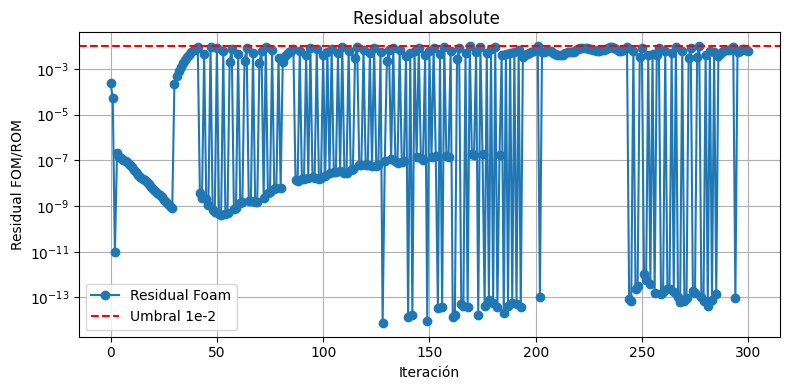

In [ ]:
import matplotlib.pyplot as plt

# Eje X: índice de cada iteración
x = list(range(len(lista_residual_foam)))

# Graficar
plt.figure(figsize=(8, 4))
plt.plot(x, lista_residual_foam, marker='o', linestyle='-', label='Residual Foam')

# Línea horizontal en 1e-2 (10^-2)
plt.axhline(y=1e-2, color='red', linestyle='--', label='Umbral 1e-2')

# Etiquetas y detalles
plt.title("Residual absolute ")
plt.xlabel("Iteración")
plt.ylabel("Residual FOM/ROM")
plt.yscale('log')  # Escala logarítmica en Y (opcional pero común en residuos)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()